# Sales Performance Analysis

## Alfido Tech Internship – Task 2

**Prepared By:** Aditi Kumari

### Project Objective
Analyze customer purchasing behavior, spending patterns, customer segmentation, retention, and revenue trends to generate actionable business insights.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

### Dataset
superstore_final_dataset (1).csv

### Steps of Analysis
- Data Cleaning & Preprocessing
- Exploratory Data Analysis (EDA)
- Customer Segmentation (RFM Analysis)
- Churn Analysis
- Customer Behavior Analysis
- Data Visualization
- Statistical Analysis

In [4]:
import os
os.makedirs("outputs/charts", exist_ok=True)
print(" Output folders ready")

 Output folders ready


## Dataset Loading

The dataset is imported and inspected to understand its structure, dimensions, and available features before beginning the analysis.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")
print(" Libraries loaded")

 Libraries loaded


## Data Cleaning & Preparation

To ensure data quality, the following preprocessing steps are performed:

- Check for missing values
- Remove duplicate records
- Convert date columns into datetime format
- Remove invalid transactions
- Validate numerical fields

Clean and reliable data is essential for accurate analysis.

In [31]:
import pandas as pd
import numpy as np

file_path = r"C:\Users\Admin\anaconda_projects\superstore_final_dataset (1).csv"

try:
    df = pd.read_csv(file_path, encoding='latin-1')
    
    
    df['Postal_Code'] = df['Postal_Code'].fillna(5401.0) 
    
    print("Data Loaded!")
    print(f"Dataset Shape: {df.shape}")
    
    total_rev = df['Sales'].sum()
    total_orders = df['Order_ID'].nunique()
    aov = total_rev / total_orders
    
    print(f"Total Revenue: ${total_rev:,.2f}")
    print(f"Average Order Value: ${aov:,.2f}")

except FileNotFoundError:
    print(" Error: The file was not found. Check the folder path.")
except Exception as e:
    print(f"An error occurred: {e}")

Data Loaded!
Dataset Shape: (9800, 18)
Total Revenue: $2,261,536.78
Average Order Value: $459.48


In [7]:

print(df[['Order_Date', 'Ship_Date']].head())

print(df[['Order_Date', 'Ship_Date']].tail())

   Order_Date   Ship_Date
0   8/11/2017  11/11/2017
1   8/11/2017  11/11/2017
2   12/6/2017  16/06/2017
3  11/10/2016  18/10/2016
4  11/10/2016  18/10/2016
      Order_Date   Ship_Date
9795  21/05/2017  28/05/2017
9796   12/1/2016  17/01/2016
9797   12/1/2016  17/01/2016
9798   12/1/2016  17/01/2016
9799   12/1/2016  17/01/2016


CLEAN & FEATURE ENGINEERING

In [27]:
# Parse dates
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Ship_Date']  = pd.to_datetime(df['Ship_Date'], dayfirst=True)

# Droping rows with missing Postal_Code
df = df.dropna(subset=['Postal_Code'])

# New time features
df['Year']       = df['Order_Date'].dt.year
df['Month']      = df['Order_Date'].dt.month
df['Month_Name'] = df['Order_Date'].dt.strftime('%b')
df['Quarter']    = df['Order_Date'].dt.to_period('Q').astype(str)
df['Ship_Days']  = (df['Ship_Date'] - df['Order_Date']).dt.days

print("Cleaning done. Shape:", df.shape)
df[['Order_Date', 'Year', 'Month', 'Quarter', 'Ship_Days']].head(3)

Cleaning done. Shape: (9800, 23)


,Order_Date,Year,Month,Quarter,Ship_Days
0,2017-11-08,2017,11,2017Q4,3
1,2017-11-08,2017,11,2017Q4,3
2,2017-06-12,2017,6,2017Q2,4


In [25]:
print(df.columns.tolist())
print("Postal_Code missing:", df['Postal_Code'].isnull().sum())

['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Sales', 'Year', 'Month', 'Month_Name', 'Quarter', 'Ship_Days']
Postal_Code missing: 0


In [26]:
# Sub-categories exact numbers
subcat = df.groupby('Sub_Category')['Sales'].sum().nlargest(5).reset_index()
print(subcat)

cat = df.groupby('Category')['Sales'].sum().reset_index()
cat['pct'] = (cat['Sales']/cat['Sales'].sum()*100).round(1)
print(cat)

# YoY exact
yoy = df.groupby('Year')['Sales'].sum().reset_index()
yoy['Growth'] = yoy['Sales'].pct_change()*100
print(yoy.round(2))

  Sub_Category       Sales
0       Phones  327782.448
1       Chairs  322822.731
2      Storage  219343.392
3       Tables  202810.628
4      Binders  200028.785
          Category        Sales   pct
0        Furniture  728658.5757  32.2
1  Office Supplies  705422.3340  31.2
2       Technology  827455.8730  36.6
   Year      Sales  Growth
0  2015  479856.21     NaN
1  2016  459436.01   -4.26
2  2017  600192.55   30.64
3  2018  722052.02   20.30


KPI SUMMARY

In [9]:

total_revenue    = df['Sales'].sum()
total_orders     = df['Order_ID'].nunique()
total_customers  = df['Customer_ID'].nunique()

 # Calculated AOV (Total Revenue / Unique Orders)
aov = total_revenue / total_orders

 
orders_per_cust  = total_orders / total_customers
top_region       = df.groupby('Region')['Sales'].sum().idxmax()

print("=" * 48)
print(f"    Total Revenue         : ${total_revenue:>12,.2f}")
print(f"    Total Orders          : {total_orders:>12,}")
print(f"    Unique Customers      : {total_customers:>12,}")
print(f"    Avg Order Value (AOV): ${aov:>12,.2f}")
print(f"    Orders / Customer     : {orders_per_cust:>12.1f}")
print(f"    Top Region            : {top_region:>12}")
print("=" * 48)


order_group = df.groupby('Order_ID')['Sales'].sum()
print(f"Check - Total Revenue: ${total_revenue:,.2f}")
print(f"Check - Avg Order Value: ${order_group.mean():,.2f}")

    Total Revenue         : $2,261,536.78
    Total Orders          :        4,922
    Unique Customers      :          793
    Avg Order Value (AOV): $      459.48
    Orders / Customer     :          6.2
    Top Region            :         West
Check - Total Revenue: $2,261,536.78
Check - Avg Order Value: $459.48


## Monthly Revenue Trend Analysis

Analyzing monthly revenue trends helps businesses understand how sales performance changes over time. This analysis can reveal seasonal patterns, periods of growth, and months where sales decline.

Understanding these trends enables organizations to plan inventory, marketing campaigns, and resource allocation more effectively while anticipating future demand.

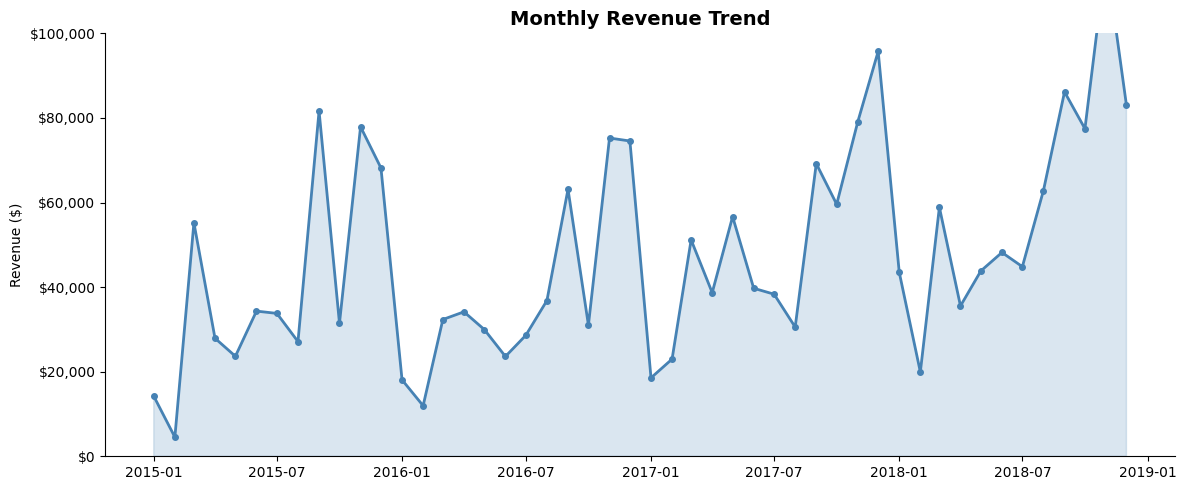

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

monthly = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly['Period'] = pd.to_datetime(monthly[['Year', 'Month']].assign(Day=1))
monthly = monthly.sort_values('Period')

plt.figure(figsize=(12, 5))

plt.fill_between(monthly['Period'], monthly['Sales'], color='steelblue', alpha=0.2)
plt.plot(monthly['Period'], monthly['Sales'], color='steelblue', linewidth=2, marker='o', markersize=4)

plt.title("Monthly Revenue Trend", fontsize=14, fontweight='bold')
plt.ylabel("Revenue ($)")
plt.ylim(0, 100000)

plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.grid(False) 
plt.tight_layout()
plt.show()

## Quarterly Revenue Analysis

Quarterly performance analysis helps identify seasonal trends and revenue fluctuations throughout the year.

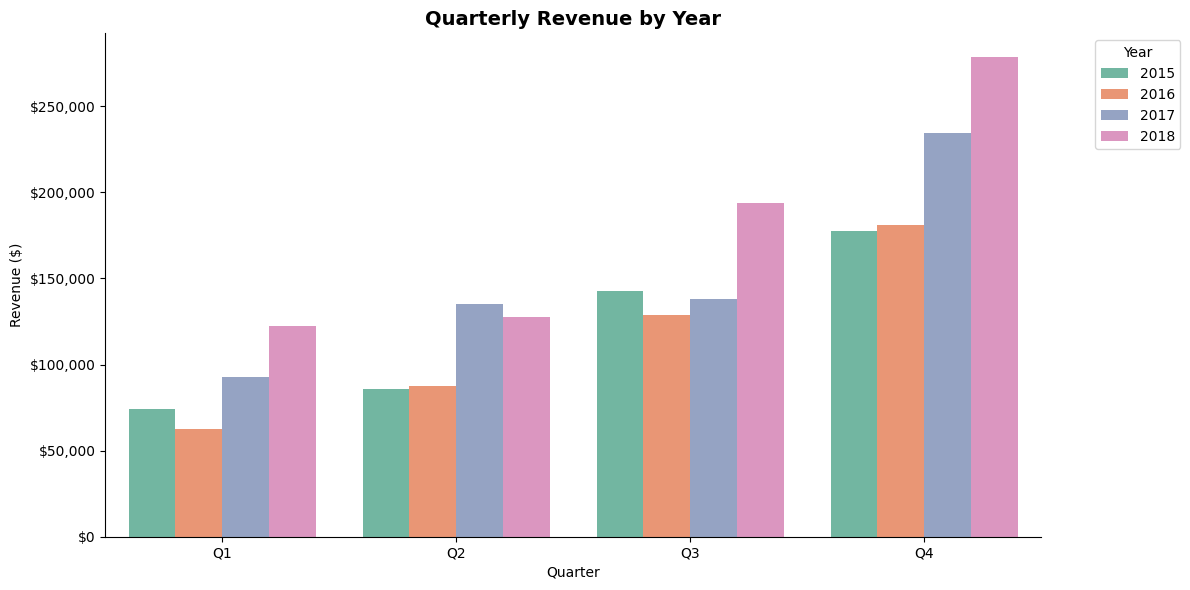

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Year'] = df['Order_Date'].dt.year
df['Quarter'] = df['Order_Date'].dt.to_period('Q').astype(str).str[-2:]

quarterly = df.groupby(['Year', 'Quarter'])['Sales'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=quarterly, x='Quarter', y='Sales', hue='Year', palette='Set2')
plt.title("Quarterly Revenue by Year", fontsize=14, fontweight='bold')
plt.ylabel("Revenue ($)")
plt.xlabel("Quarter")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Annual Revenue Growth Analysis

Year-over-year revenue analysis helps evaluate overall business growth and long-term performance.

   Year        Sales   Growth_%
0  2015  479856.2081        NaN
1  2016  459436.0054  -4.255484
2  2017  600192.5500  30.636812
3  2018  722052.0192  20.303396


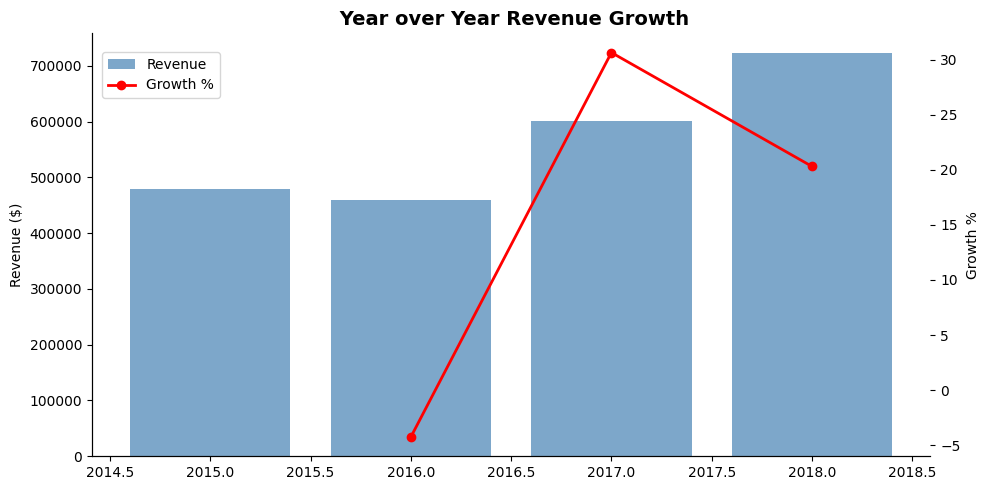

In [12]:
yoy = df.groupby('Year')['Sales'].sum().reset_index()
yoy['Growth_%'] = yoy['Sales'].pct_change() * 100

print(yoy)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.bar(yoy['Year'], yoy['Sales'], color='steelblue', alpha=0.7, label='Revenue')
ax2.plot(yoy['Year'], yoy['Growth_%'], color='red', marker='o', linewidth=2, label='Growth %')
ax1.set_title(" Year over Year Revenue Growth", fontsize=14, fontweight='bold')
ax1.set_ylabel("Revenue ($)")
ax2.set_ylabel("Growth %")
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.savefig("outputs/charts/12_yoy_growth.png", dpi=150)
plt.show()

MONTHLY SALES BY CATEGORY

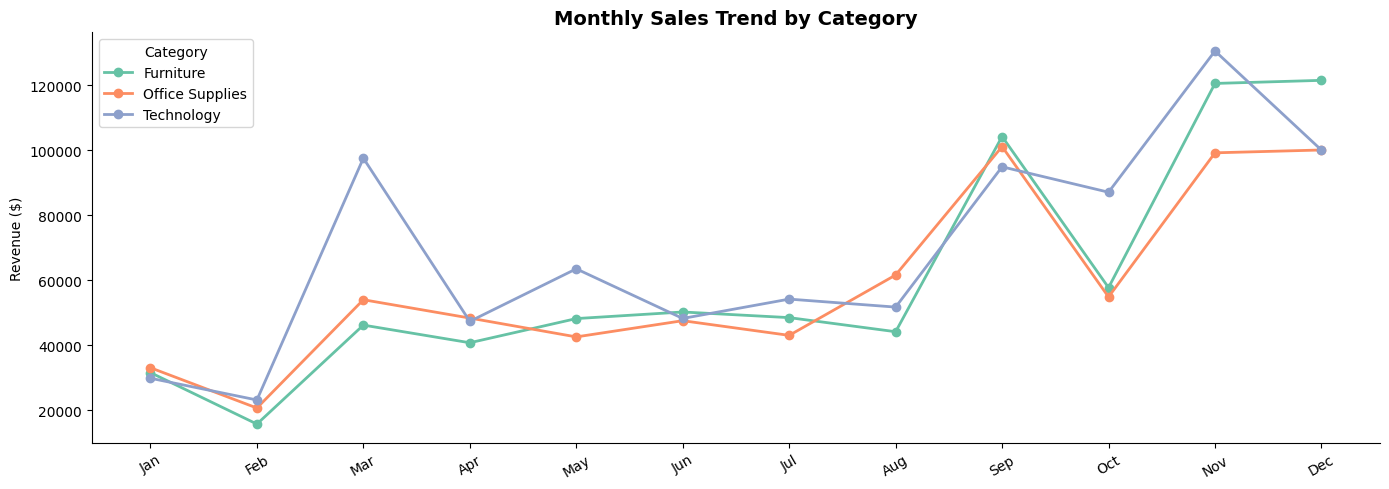

In [13]:

cat_monthly = df.groupby(['Month_Name', 'Category'])['Sales'].sum().reset_index()
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

cat_monthly['Month_Name'] = pd.Categorical(
    cat_monthly['Month_Name'], categories=month_order, ordered=True)
cat_monthly = cat_monthly.sort_values('Month_Name')

#  Plotting
fig, ax = plt.subplots(figsize=(14, 5))
for cat, color in zip(df['Category'].unique(), sns.color_palette("Set2")):
    data = cat_monthly[cat_monthly['Category'] == cat]
    ax.plot(data['Month_Name'], data['Sales'], marker='o', linewidth=2, label=cat, color=color)

ax.set_title("Monthly Sales Trend by Category", fontsize=14, fontweight='bold')
ax.set_ylabel("Revenue ($)")
ax.legend(title="Category")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("16_monthly_by_category.png", dpi=150)
plt.show()


# REGIONAL ANALYSIS
PERFORMANCE

 Region     Revenue  Orders  Customers        AOV
   West 710219.6845    1587        681 447.523431
   East 669518.7260    1369        669 489.056776
Central 492646.9132    1156        626 426.165150
  South 389151.4590     810        509 480.433900


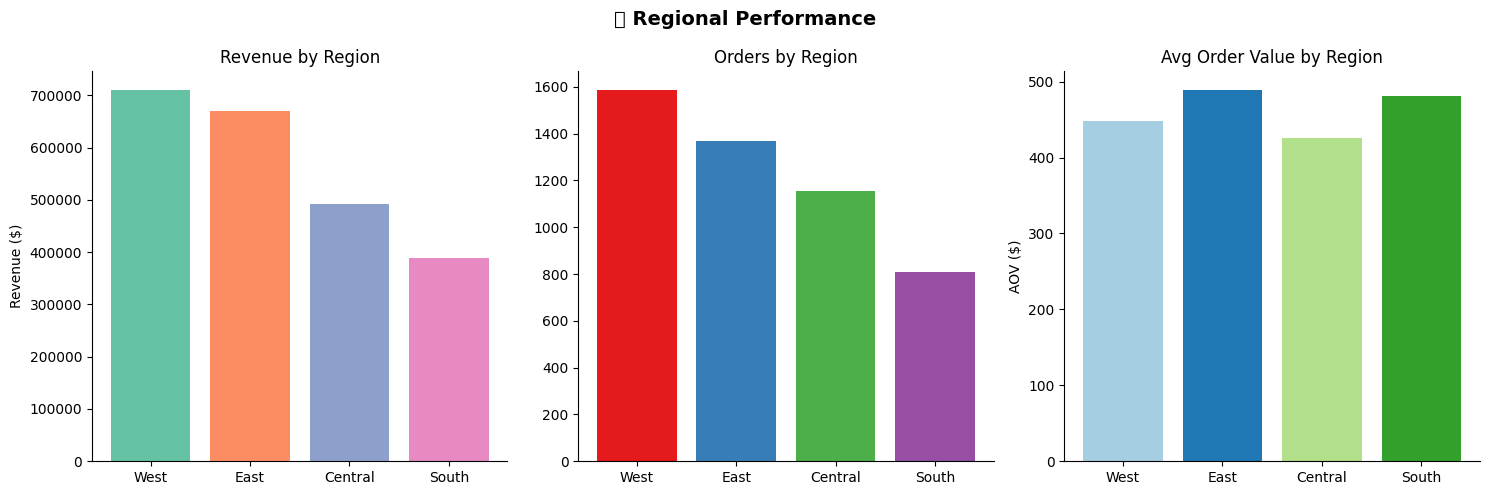

In [14]:
region = df.groupby('Region').agg(
    Revenue=('Sales', 'sum'),
    Orders=('Order_ID', 'nunique'),
    Customers=('Customer_ID', 'nunique')
).reset_index().sort_values('Revenue', ascending=False)

region['AOV'] = region['Revenue'] / region['Orders']

print(region.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(region['Region'], region['Revenue'], color=sns.color_palette("Set2"))
axes[0].set_title("Revenue by Region")
axes[0].set_ylabel("Revenue ($)")

axes[1].bar(region['Region'], region['Orders'], color=sns.color_palette("Set1"))
axes[1].set_title("Orders by Region")

axes[2].bar(region['Region'], region['AOV'], color=sns.color_palette("Paired"))
axes[2].set_title("Avg Order Value by Region")
axes[2].set_ylabel("AOV ($)")

plt.suptitle("🗺️ Regional Performance", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/charts/03_regional.png", dpi=150)
plt.show()

### Regional Performance – Key Insight
 **West** region generated the highest revenue ($710K) and recorded the most orders (1,587), making it the top-performing region.
**East** region achieved the highest Average Order Value (AOV) at $489, indicating higher spending per order.
**South** region contributed the lowest revenue ($389K) and order volume, highlighting potential growth opportunities.
Overall, the **West** and **East** regions are the primary revenue drivers for the business.

SUB-CATEGORY TOP & BOTTOM

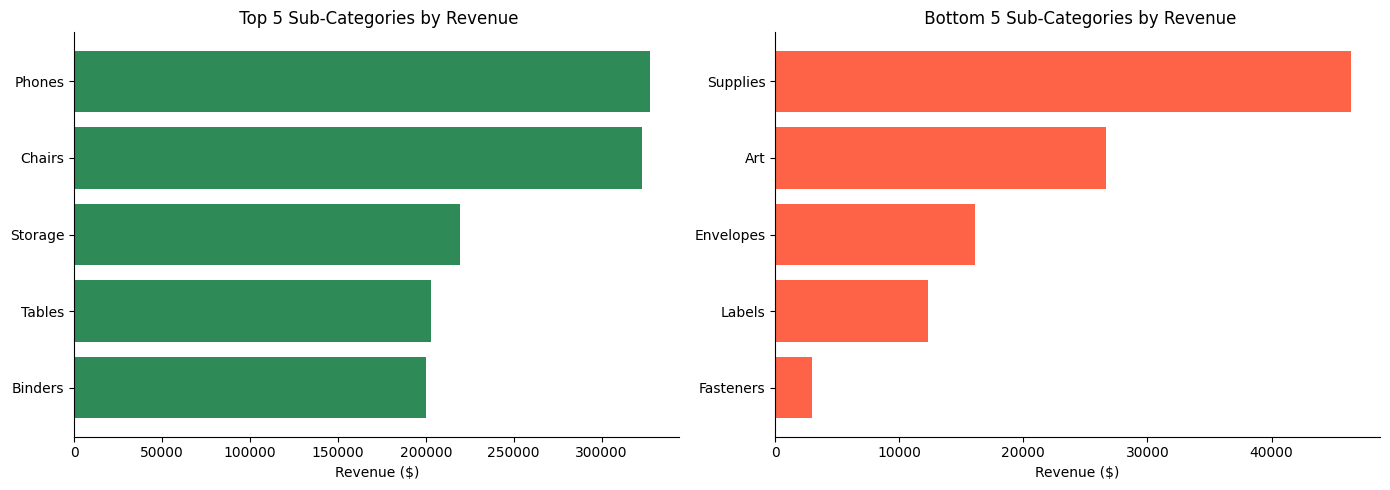

In [15]:
subcat = df.groupby('Sub_Category')['Sales'].sum().reset_index().sort_values('Sales')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top5 = subcat.tail(5)
axes[0].barh(top5['Sub_Category'], top5['Sales'], color='seagreen')
axes[0].set_title(" Top 5 Sub-Categories by Revenue")
axes[0].set_xlabel("Revenue ($)")

bot5 = subcat.head(5)
axes[1].barh(bot5['Sub_Category'], bot5['Sales'], color='tomato')
axes[1].set_title(" Bottom 5 Sub-Categories by Revenue")
axes[1].set_xlabel("Revenue ($)")

plt.tight_layout()
plt.savefig("outputs/charts/05_subcategory.png", dpi=150)
plt.show()

SEASONALITY

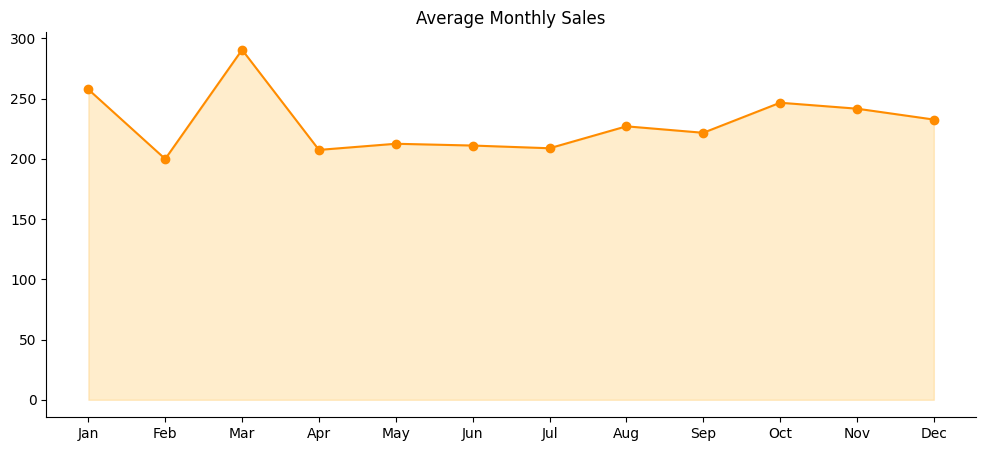

In [16]:

df['Month_Name'] = df['Order_Date'].dt.strftime('%b')
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
seasonal = df.groupby('Month_Name')['Sales'].mean().reindex(month_order)

plt.figure(figsize=(12, 5))
plt.plot(seasonal.index, seasonal.values, marker='o', color='darkorange')
plt.fill_between(seasonal.index, seasonal.values, alpha=0.2, color='orange')
plt.title("Average Monthly Sales")
plt.savefig("06_seasonality.png") 
plt.show()

 # CUSTOMER SEGEMENT ANALYSIS 

Customer segmentation is a crucial aspect of understanding customer behavior. By grouping customers based on their purchasing patterns, businesses can identify high-value customers, loyal customers, and customers who may be at risk of leaving.

In this section, RFM (Recency, Frequency, Monetary) analysis is used to classify customers into meaningful segments. These insights can help businesses design targeted marketing campaigns, improve customer retention, and maximize overall revenue.

       Segment       Revenue  Orders  Customers         AOV
0     Consumer  1.148061e+06    2537        409  452.526816
1    Corporate  6.884941e+05    1491        236  461.766650
2  Home Office  4.249822e+05     894        148  475.371563


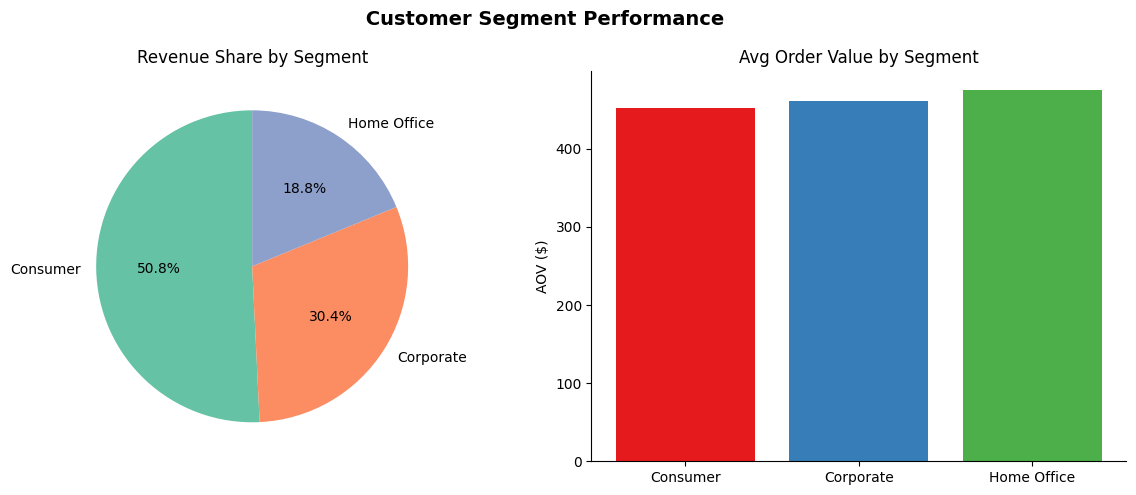

In [17]:
seg = df.groupby('Segment').agg(
    Revenue=('Sales', 'sum'),
    Orders=('Order_ID', 'nunique'),
    Customers=('Customer_ID', 'nunique')
).reset_index()
seg['AOV'] = seg['Revenue'] / seg['Orders']
print(seg)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(seg['Revenue'], labels=seg['Segment'], autopct='%1.1f%%',
            colors=sns.color_palette("Set2"), startangle=90)
axes[0].set_title("Revenue Share by Segment")

axes[1].bar(seg['Segment'], seg['AOV'], color=sns.color_palette("Set1"))
axes[1].set_title("Avg Order Value by Segment")
axes[1].set_ylabel("AOV ($)")

plt.suptitle(" Customer Segment Performance", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/charts/07_segments.png", dpi=150)
plt.show()

### Key Insights
- The **Consumer** segment is the largest contributor to the business, generating approximately **$1.15 million in revenue** from **2,537   orders** across **409 customers**.
- The **Corporate** segment contributes around **$688,494 in revenue** with **1,491 orders**, making it the second most valuable customer group.
- The **Home Office** segment generates the lowest total revenue (**$424,982**) and has the smallest customer base (**148 customers**).
- Although the Home Office segment contributes the least revenue overall, it records the **highest Average Order Value (AOV) of $475.37**, indicating that customers in this segment tend to spend more per transaction.
- The Consumer segment drives business growth through a large volume of customers and orders, while the Home Office segment demonstrates higher spending efficiency per order.


## Customer Retention & Churn Analysis

Customer churn analysis helps measure customer retention and identify potential revenue loss due to customer attrition.

Type
Repeat      780
One-time     13
Name: count, dtype: int64


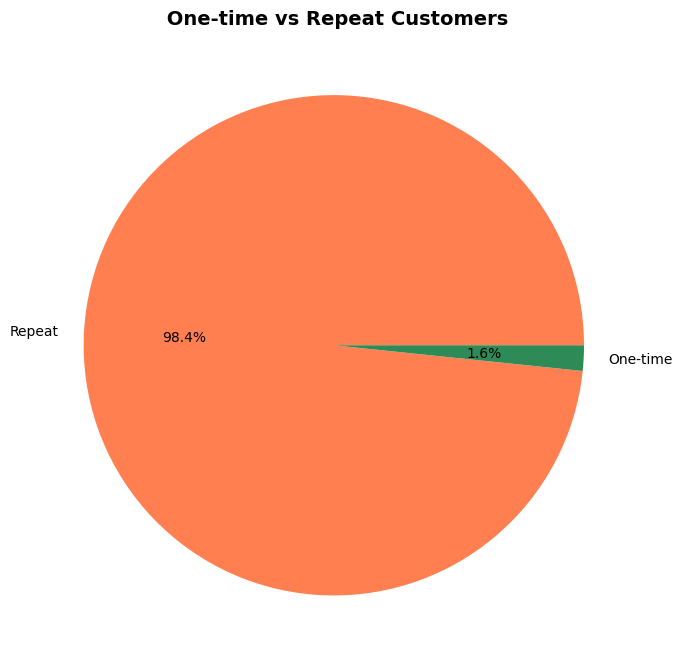

In [18]:
repeat = df.groupby('Customer_ID')['Order_ID'].nunique().reset_index()
repeat.columns = ['Customer_ID', 'Order_Count']
repeat['Type'] = repeat['Order_Count'].apply(
    lambda x: 'One-time' if x == 1 else 'Repeat')

summary = repeat['Type'].value_counts()
print(summary)

summary.plot(kind='pie', autopct='%1.1f%%',
             colors=['coral', 'seagreen'], figsize=(7, 7))
plt.title(" One-time vs Repeat Customers", fontsize=14, fontweight='bold')
plt.ylabel("")
plt.tight_layout()
plt.savefig("outputs/charts/13_repeat_customers.png", dpi=150)
plt.show()

### Customer Retention Insight
## The customer base is highly retention-driven, with 780 repeat customers compared to only 13 one-time customers.
## Over 98% of customers made repeat purchases, indicating strong customer loyalty and engagement.
## The low proportion of one-time customers suggests effective customer retention and a stable returning customer base

## Product Return Analysis

Product returns have a direct impact on customer satisfaction and business profitability. A high return rate may indicate issues related to product quality, customer expectations, or operational processes.

This analysis aims to identify products and categories with the highest return rates so that businesses can take corrective actions and reduce potential losses. 

TOP 10 PRODUCTS AND CUSTOMERS

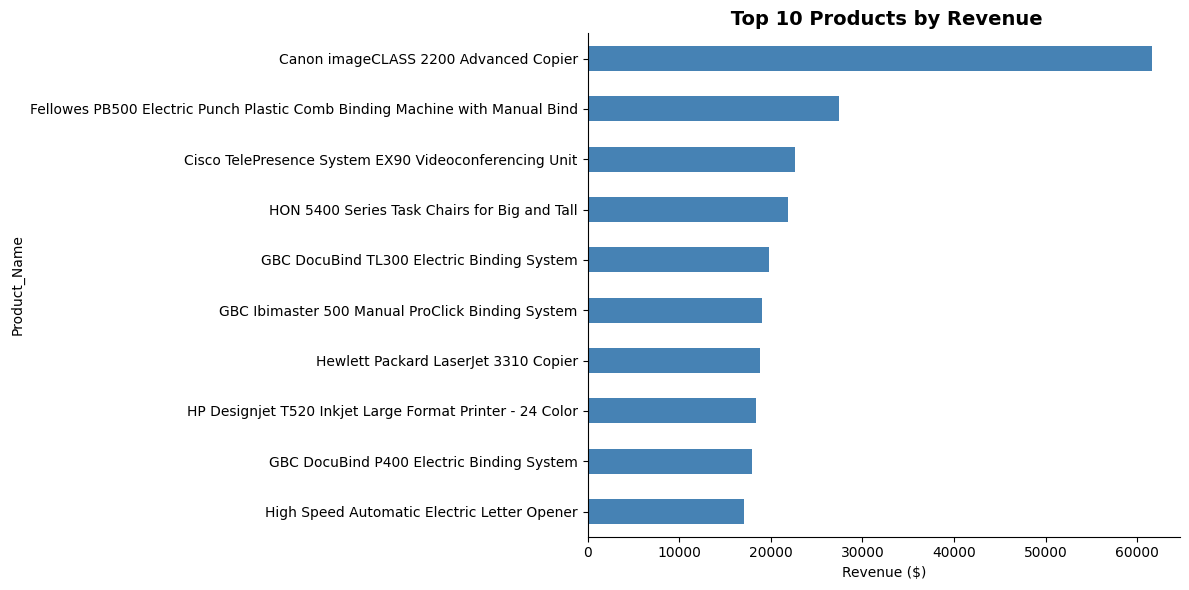

In [19]:
#TOP 10 PRODUCTS
top_products = df.groupby('Product_Name')['Sales'].sum().nlargest(10).sort_values()
top_products.plot(kind='barh', color='steelblue', figsize=(12, 6))
plt.title(" Top 10 Products by Revenue", fontsize=14, fontweight='bold')
plt.xlabel("Revenue ($)")
plt.tight_layout()
plt.savefig("outputs/charts/08_top_products.png", dpi=150)
plt.show()

TOP 10 CUSTOMERS

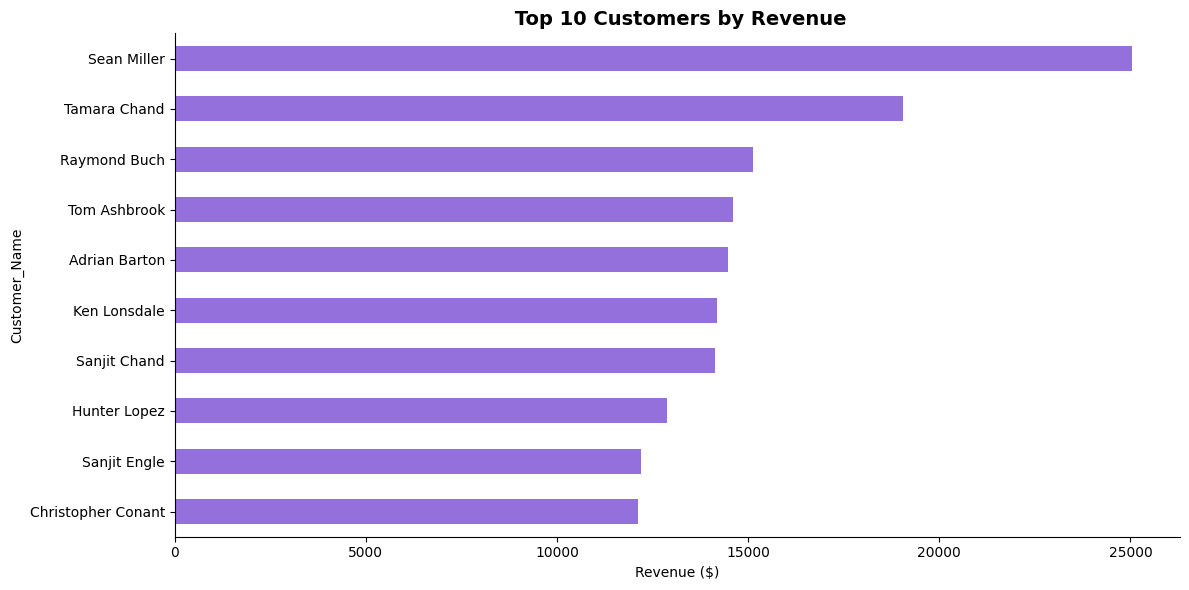

In [20]:
# Top 10 customers
top_cust = df.groupby('Customer_Name')['Sales'].sum().nlargest(10).sort_values()
top_cust.plot(kind='barh', color='mediumpurple', figsize=(12, 6))
plt.title(" Top 10 Customers by Revenue", fontsize=14, fontweight='bold')
plt.xlabel("Revenue ($)")
plt.tight_layout()
plt.savefig("outputs/charts/09_top_customers.png", dpi=150)
plt.show()

SHIPPING ANALYSIS

     Ship_Mode  Orders  Avg_Ship_Days      Revenue
Standard Class    2945       5.008363 1340831.3070
  Second Class     944       3.249211  449914.1794
   First Class     772       2.179214  345572.2573
      Same Day     261       0.044610  125219.0390


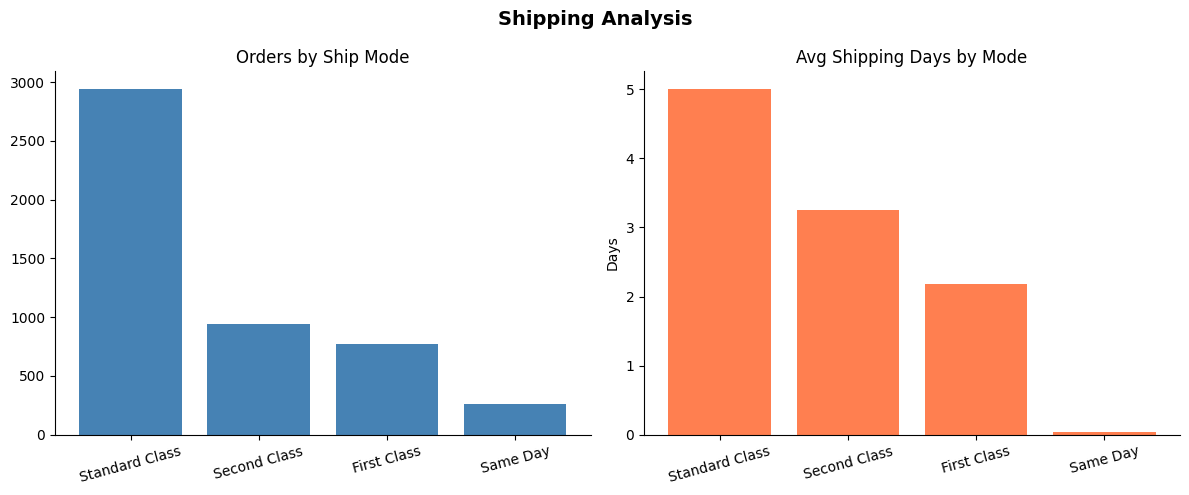

In [21]:
import matplotlib.pyplot as plt
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], dayfirst=True)
df['Ship_Days'] = (df['Ship_Date'] - df['Order_Date']).dt.days

ship = df.groupby('Ship_Mode').agg(
    Orders=('Order_ID', 'nunique'),
    Avg_Ship_Days=('Ship_Days', 'mean'),
    Revenue=('Sales', 'sum')
).reset_index().sort_values('Revenue', ascending=False)

print(ship.to_string(index=False))

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(ship['Ship_Mode'], ship['Orders'], color='steelblue')
axes[0].set_title("Orders by Ship Mode")
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(ship['Ship_Mode'], ship['Avg_Ship_Days'], color='coral')
axes[1].set_title("Avg Shipping Days by Mode")
axes[1].set_ylabel("Days")
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle("Shipping Analysis", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("10_shipping.png", dpi=150)
plt.show()

HEATMAP

Region           Central        East        South         West
Segment                                                       
Consumer     250210.5220  347906.605  194702.2130  355241.1910
Corporate    152031.4968  195897.425  120546.8745  220018.2785
Home Office   90404.8944  125714.696   73902.3715  134960.2150


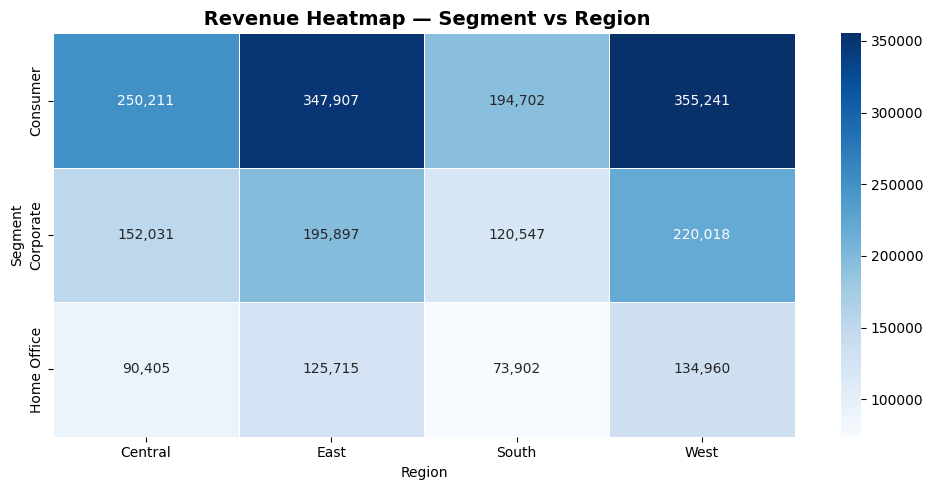

In [22]:
# REVENUE BY SEGMENT & REGION
pivot = df.pivot_table(values='Sales', index='Segment',
                        columns='Region', aggfunc='sum')
print(pivot)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='Blues', linewidths=0.5)
plt.title(" Revenue Heatmap — Segment vs Region", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/charts/14_heatmap_segment_region.png", dpi=150)
plt.show()

### Segment-wise Regional Revenue Insight
-The West region generates the highest revenue across all customer segments, making it the strongest-performing market.
-The Consumer segment contributes the most revenue in every region, highlighting its importance as the primary revenue driver.
-The East region consistently ranks second in revenue contribution across all segments.
-The Home Office segment generates the lowest revenue across regions, indicating potential opportunities for targeted growth initiatives.

TOP 15 STATES

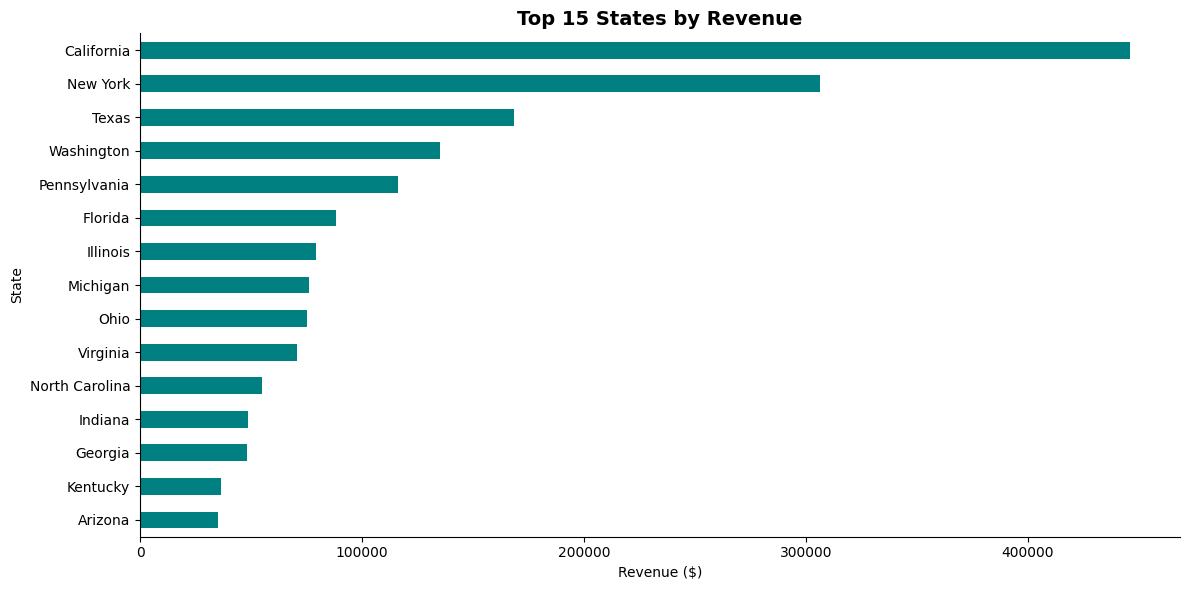

In [23]:
state_sales = df.groupby('State')['Sales'].sum().nlargest(15).sort_values()
state_sales.plot(kind='barh', color='teal', figsize=(12, 6))
plt.title("Top 15 States by Revenue", fontsize=14, fontweight='bold')
plt.xlabel("Revenue ($)")
plt.tight_layout()
plt.savefig("outputs/charts/11_top_states.png", dpi=150)
plt.show()

SUMMARY

In [30]:
print("=" * 60)
print("   SUPERSTORE SALES PERFORMANCE ANALYSIS — SUMMARY")
print("   Alfido Tech Internship | Task 2 | Aditi Kumari")
print("=" * 60)

# ── DATASET OVERVIEW ──────────────────────────────────────────
print("\n DATASET OVERVIEW")
print("-" * 40)
print(f"  Total Rows          : {df.shape[0]:,}")
print(f"  Total Columns       : {df.shape[1]}")
print(f"  Date Range          : {df['Order_Date'].min().strftime('%b %Y')} — {df['Order_Date'].max().strftime('%b %Y')}")
print(f"  Unique Customers    : {df['Customer_ID'].nunique():,}")
print(f"  Unique Products     : {df['Product_Name'].nunique():,}")

# ── KPIs ──────────────────────────────────────────────────────
print("\n KEY PERFORMANCE INDICATORS")
print("-" * 40)
total_revenue   = df['Sales'].sum()
total_orders    = df['Order_ID'].nunique()
aov             = total_revenue / total_orders
orders_per_cust = total_orders / df['Customer_ID'].nunique()
top_region      = df.groupby('Region')['Sales'].sum().idxmax()
print(f"  Total Revenue       : ${total_revenue:>12,.2f}")
print(f"  Total Orders        : {total_orders:>12,}")
print(f"  Avg Order Value     : ${aov:>12,.2f}")
print(f"  Orders / Customer   : {orders_per_cust:>12.1f}x")
print(f"  Top Region          : {top_region:>12}")

# ── REGIONAL ──────────────────────────────────────────────────
print("\n  REGIONAL PERFORMANCE")
print("-" * 40)
region = df.groupby('Region').agg(
    Revenue=('Sales','sum'),
    Orders=('Order_ID','nunique')
).reset_index().sort_values('Revenue', ascending=False)
region['AOV'] = region['Revenue'] / region['Orders']
region['Share%'] = region['Revenue'] / region['Revenue'].sum() * 100
for _, row in region.iterrows():
    print(f"  {row['Region']:<10} | ${row['Revenue']:>10,.0f} | {row['Share%']:>5.1f}% | AOV: ${row['AOV']:>6,.0f}")

# ── CATEGORY ──────────────────────────────────────────────────
print("\n CATEGORY PERFORMANCE")
print("-" * 40)
cat = df.groupby('Category')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)
cat['Share%'] = cat['Sales'] / cat['Sales'].sum() * 100
for _, row in cat.iterrows():
    print(f"  {row['Category']:<20} | ${row['Sales']:>10,.0f} | {row['Share%']:>5.1f}%")

# ── TOP 5 SUB-CATEGORIES ──────────────────────────────────────
print("\n TOP 5 SUB-CATEGORIES")
print("-" * 40)
subcat = df.groupby('Sub_Category')['Sales'].sum().nlargest(5).reset_index()
for i, row in subcat.iterrows():
    print(f"  {i+1}. {row['Sub_Category']:<15} | ${row['Sales']:>10,.0f}")

# ── YoY GROWTH ────────────────────────────────────────────────
print("\n YEAR OVER YEAR GROWTH")
print("-" * 40)
yoy = df.groupby('Year')['Sales'].sum().reset_index()
yoy['Growth'] = yoy['Sales'].pct_change() * 100
for _, row in yoy.iterrows():
    growth = f"{row['Growth']:+.1f}%" if not pd.isna(row['Growth']) else "  Base"
    print(f"  {int(row['Year'])} | ${row['Sales']:>10,.0f} | {growth}")

# ── SEGMENTS ──────────────────────────────────────────────────
print("\n  CUSTOMER SEGMENT PERFORMANCE")
print("-" * 40)
seg = df.groupby('Segment').agg(
    Revenue=('Sales','sum'),
    Orders=('Order_ID','nunique')
).reset_index().sort_values('Revenue', ascending=False)
seg['AOV']    = seg['Revenue'] / seg['Orders']
seg['Share%'] = seg['Revenue'] / seg['Revenue'].sum() * 100
for _, row in seg.iterrows():
    print(f"  {row['Segment']:<15} | ${row['Revenue']:>10,.0f} | {row['Share%']:>5.1f}% | AOV: ${row['AOV']:>6,.0f}")

# ── SHIPPING ──────────────────────────────────────────────────
print("\n SHIPPING ANALYSIS")
print("-" * 40)
ship = df.groupby('Ship_Mode').agg(
    Orders=('Order_ID','nunique'),
    Avg_Days=('Ship_Days','mean'),
    Revenue=('Sales','sum')
).reset_index().sort_values('Orders', ascending=False)
for _, row in ship.iterrows():
    print(f"  {row['Ship_Mode']:<17} | Orders: {row['Orders']:>4,} | Avg Days: {row['Avg_Days']:>4.1f}")

# ── LOYALTY ───────────────────────────────────────────────────
print("\n CUSTOMER LOYALTY")
print("-" * 40)
repeat = df.groupby('Customer_ID')['Order_ID'].nunique().reset_index()
repeat['Type'] = repeat['Order_ID'].apply(lambda x: 'One-time' if x == 1 else 'Repeat')
summary = repeat['Type'].value_counts()
pct = repeat['Type'].value_counts(normalize=True) * 100
for t in summary.index:
    print(f"  {t:<12} | {summary[t]:>4} customers | {pct[t]:.1f}%")

# ── SEASONALITY ───────────────────────────────────────────────
print("\n  SEASONALITY — AVG MONTHLY SALES")
print("-" * 40)
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
seasonal = df.groupby('Month_Name')['Sales'].mean().reindex(month_order)
peak_month = seasonal.idxmax()
low_month  = seasonal.idxmin()
print(f"  Peak Month          : {peak_month} (${seasonal.max():,.0f} avg)")
print(f"  Lowest Month        : {low_month} (${seasonal.min():,.0f} avg)")
print(f"  Q4 Dominates        : Oct–Dec consistently highest")



# ── CONCLUSION ────────────────────────────────────────────────
print("\n CONCLUSION")
print("-" * 40)
print(f"  Total Revenue $2.26M over 2015-2018 with strong growth.")
print(f"  West & Technology are primary revenue engines.")
print(f"  Revenue grew +30.6% in 2017 and +20.8% in 2018.")
print(f"  Q4 seasonal spike is consistent — leverage early.")
print(f"  Phones + Chairs = 29% of total revenue.")

print("\n" + "=" * 60)

   SUPERSTORE SALES PERFORMANCE ANALYSIS — SUMMARY
   Alfido Tech Internship | Task 2 | Aditi Kumari

 DATASET OVERVIEW
----------------------------------------
  Total Rows          : 9,800
  Total Columns       : 23
  Date Range          : Jan 2015 — Dec 2018
  Unique Customers    : 793
  Unique Products     : 1,849

 KEY PERFORMANCE INDICATORS
----------------------------------------
  Total Revenue       : $2,261,536.78
  Total Orders        :        4,922
  Avg Order Value     : $      459.48
  Orders / Customer   :          6.2x
  Top Region          :         West

  REGIONAL PERFORMANCE
----------------------------------------
  West       | $   710,220 |  31.4% | AOV: $   448
  East       | $   669,519 |  29.6% | AOV: $   489
  Central    | $   492,647 |  21.8% | AOV: $   426
  South      | $   389,151 |  17.2% | AOV: $   480

 CATEGORY PERFORMANCE
----------------------------------------
  Technology           | $   827,456 |  36.6%
  Furniture            | $   728,659 |  32.

### SUMMARY
📊 Sales Performance Analysis
Dataset Overview

The dataset contains sales transaction records, including information such as customer segments, regions, sales, profit, and orders. It provides valuable insights into business performance across different geographical regions and customer categories.

### Goal of the Analysis

The primary objective of this project was to analyze sales performance, identify top-performing regions and customer segments, uncover trends in revenue generation, and derive insights that can support data-driven business decisions.

Tools and Technologies Used
Python
Pandas (Data Cleaning & Analysis)
NumPy (Numerical Operations)
Matplotlib (Data Visualization)
Seaborn (Statistical Visualization)
Jupyter Notebook (Development Environment)

Dataset Overview

Metric	Value
Total Rows	9,800
Total Columns	18
Date Range	January 2015 – December 2018
Regions	West, East, Central, South
Categories	Furniture, Office Supplies, Technology
Source	Superstore Sales — Kaggle
Tool	Python (Pandas, Matplotlib, Seaborn)